# 情報システム概論　第4回
## ニューラルネットワーク

### どうしてニューラルネットワークについて学ぶのか？
パーセプトロンは層を重ねることで複雑な処理であっても表現することができるが，重みの設定は人が手で行っていた．
パーセプトロンを一般化したニューラルネットワークでは，多層になっても適切な重みパラメータをデータから自動的に学習する事ができる．

今回は，ニューラルネットワークの概要を説明し，ニューラルネットワークが識別を行う際の処理に焦点を当てる．そして，その後の授業で重みパラメータを学習する方法について学ぶ．

### パーセプトロンからニューラルネットワークへ
ニューラルネットワークはパーセプトロンと共通する点が多くある．ここではパーセプトロンと異なる点を中心に，ニューラルネットワークの仕組みを説明する．

#### ニューラルネットワークの例

<img alt="neuralnet.png" width="200" src="http://drive.google.com/uc?export=view&id=1scmo7AewHdqUxU8SU-7WGs6UPw_aaycZ">

パーセプトロンと同じ形をしていることがわかる．実際，ニューロンの繋がり方に関してはパーセプトロンと変わりない．
(ニューロンの中身が違う？)

> 前回のパーセプトロンのテキストの最後の多層パーセプトロンの図とよく似ていることがわかると思います．

#### パーセプトロンの復習

<img alt="perceptron.png" width="180" src="http://drive.google.com/uc?export=view&id=18TCRbGHhnP4iCU56hzkG_wPeSiF4STLg">

$$
y = \begin{cases}
0 & (b + w_1x_1 + w_2x_2 \le 0) \\
1 & (b + w_1x_1 + w_2x_2 > 0)
\end{cases}
$$

上の図はパーセプトロンで，上の数式のようにあらわされたことを思い出そう．
ここで，bは「バイアス」と呼ばれるパラメータで，これはニューロンの発火のしやすさをコントロールする．
ところで，上の図のネットワークにはバイアスbが図示されていない．もしバイアスを明示するならば，下の図のように表すことができる．

<img alt="bias.png" width="180" src="http://drive.google.com/uc?export=view&id=1JMLljAAIyonrzmhJN7KhT4odLx3AlqgA">

重みがbで入力が1の信号が追加されていることがわかる．このパーセプトロンの動作は，x1とx2と1の3つの信号がニューロンの入力となり，それら3つの信号にそれぞれの重みが乗算され，次のニューロンに送信される．次のニューロンでは，それらの重み付けされた信号の和が計算され，その和が0を超えたら1を出力し，そうでなければ0を出力する．ちなみにバイアスは常に1であるため，図で表す際には，ニューロンを灰色で塗りつぶし，他のニューロンと差別化することにする．

> ここで言っているのは，前回習ったパーセプトロンの動作そのものです．

それでは，このあとでニューラルネットのことを説明する準備として，上のパーセプトロンの式をシンプルな形に書き換えたい．この式を簡略化するためには，場合分けの動作 (0を超えたら1を出力し，そうでなけれあ0を出力するという動作) を一つの関数で表す．ここでは h(x) という新しい関数を導入し，次のようにパーセプトロンの式を書き換える．

$$y = h(b + w_1x_1 + w_2x_2)$$

$$h(x) = \begin{cases} 0 & (x \le 0) \\ 1 & (x > 0) \end{cases}$$

入力信号の総和がh(x)という関数によって変換され，その変換された値が出力yになるということを表す．そして，h(x)関数は，入力が0を超えたら1を返し，そうでなければ0を返す．そのため，この式は前のパーセプトロンの式と同じことを行っている．

> パーセプトロンの式を違う表現にしただけですね．新しいことは何も言っていません．

#### 活性化関数の登場
さて，ここで登場したh(x)という関数は，一般的に活性化関数 (activation function) と呼ばれ，入力信号の総和を出力に変換する役割がある．「活性化」という名前が意味するように，活性化関数は入力信号の総和がどのように活性化(どのように発火するか)ということを決定する役割がある．

> 活性化関数であるh(x) のxに入力信号の総和が入ってきて，これが0を超える場合は1を出力(発火する)して，そうじゃない場合は0を出力(発火しない)ということですね．ここでも新しいことは何も言っていなくて，h(x)を活性化関数と呼ぶと言っているだけです．

それでは，更にこの式を書き換えていく．この式は重み付きの入力信号の総和を計算し，そして，その和が活性化関数に変換される，という2段階の処理を行っている．そのため，この式を丁寧に書くとすれば次の式にわけて書くことができる．

$$
\begin{aligned}
a &= b + w_1x_1 + w_2x_2 \\
y &= h(a)
\end{aligned}
$$

この式では，重み付きの入力信号とバイアスの総和を計算し，それをaとする．そして，aがh()で変換されyが出力される，という流れになる．
この式を明示的に示すとすれば，次のように表すことができる．

<img alt="activation.png" width="250" src="http://drive.google.com/uc?export=view&id=1GLhMQS-8yXObLI1KMUA7zDXisflNJUS3">

これまでのニューロンの○の中に，活性化関数によるプロセスを明示的に図示している．つまり，重み付き信号の和の結果がaというノードになり，そして，活性化関数h()によってyというノードに変換される，ということがはっきりと示されている(ノードはニューロンと同じような意味で図の〇で表されるものです)．

> ここでも，図の書き方を丁寧にしているだけで，新しいことは何も言ってませんので安心してください．

この活性化関数がパーセプトロンからニューラルネットワークへ進むための架け橋となる．

### 活性化関数
活性化関数には様々な物があるが，ここではステップ関数，シグモイド関数，ReLU関数について説明する．

- ステップ関数：パーセプトロンの活性化関数であり，すでに説明している下記の式で表されるように，入力が0を超えたら1を出力し，それ以外は0を出力する．

$$
h(x) = \begin{cases}
0 & (x \le 0) \\
1 & (x > 0)
\end{cases}
$$

> これまで説明してきた，入力が0を超えると1になり，0を超えないと0になる関数h(x)はステップ関数と呼ぶということですね．

- シグモイド関数，ReLU関数：ニューラルネットワークで用いられる活性化関数である．例えばシグモイド関数に1.0や2.0を入力すると，h(1.0) = 0.731…，h(2.0) = 0.880…のように中途半端な値が出力する．

#### パーセプトロンとニューラルネットワークとで同じところは？違うところは？

- 同じところ
 - ニューロンの繋がり方
     - 多層につながる
     - 信号の伝達方法
- 違うところ
 - ***活性化関数だけ!!***

 > 活性化関数がステップ関数であればパーセプトロンと呼び，シグモイド関数など，ステップ関数以外の活性化関数を使っていればニューラルネットワークと呼ぶということですね．最初に説明したように，全体の構造はパーセプトロンもニューラルネットワークも同じです．

活性化関数はニューラルネットワークの部品になるので，これから活性化関数を作ることにする．

### ステップ関数を作る

ステップ関数を以下のように実装する．


In [16]:
import numpy as np

def step_function(x):
    return np.array(x > 0, dtype=np.int64)

上記の関数は，今後のことを考えて，複数の値をNumPy配列として与えられるようにしており，以下のようにして使う．

In [17]:
a = np.array([-1.0, 1.0, 2.0])
step_function(a)

array([0, 1, 1])

> ちゃんと0を超えている場合だけ1になっていることがわかりますよね．ただ，上記のステップ関数の実装は少しわかりにくいと思いますので，以下のようにばらばらにしてみましょう．

In [18]:
a > 0

array([False,  True,  True])

> これはPython入門の時にやりましたよね．0より大きいことが成り立つところだけTrueになるんですね．

In [19]:
tmp = a > 0

> いったん ```a > 0```の結果をtmpという変数に入れます．tmpの中身は```array([False,  True,  True])```のはずですね．

In [20]:
np.array(tmp, dtype=np.int64)

array([0, 1, 1])

> 最後に型をboolからintに変えています．Trueは1に，Falseは0に変換されます．```step_function(x)```の中で何をやっているのかわかりましたでしょうか．

### ステップ関数のグラフ
このステップ関数のグラフを確認してみる．

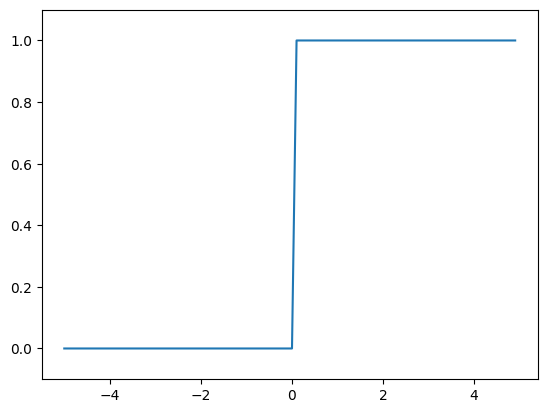

In [21]:
import matplotlib.pylab as plt

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定
plt.show()

> ```x = np.arange(-5.0, 5.0, 0.1)```がわからないですよね．これは，-5.0～5.0を0.1刻みで配列に詰め込むということです．以下のようにxの中身を表示してみるとよくわかりますね．

In [22]:
x

array([-5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -1.77635684e-14,  1.00000000e-01,
        2.00000000e-01,  

ステップ関数は0を境にして，出力が0から1 (または1から0)へ切り替わる．  
ステップ関数は階段状に値が切り替わる形から，「階段関数」と呼ばれることもある．

### シグモイド関数を作る

シグモイド関数はニューラルネットワークでよく用いられる活性化関数の一つで，以下の式で表される．

$$
h(x) = \frac{1}{1 + \mathrm{e}^{-x}}
$$

> シグモイド関数はこういうもんだということで，特に疑問を持たずに先に進んでください．

シグモイド関数を以下のように実装する．

In [23]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

上のシグモイド関数の実装は，このままで配列の入力も扱える．

> 下記のように，-1.0, 1.0, 2.0 のシグモイド関数の計算を同時にできます．

In [24]:
x = np.array([-1.0, 1.0, 2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

ちなみに，配列ではなくスカラ値でもOK

In [25]:
sigmoid(1.0)

np.float64(0.7310585786300049)

### シグモイド関数のグラフ
シグモイド関数のグラフを確認してみる．

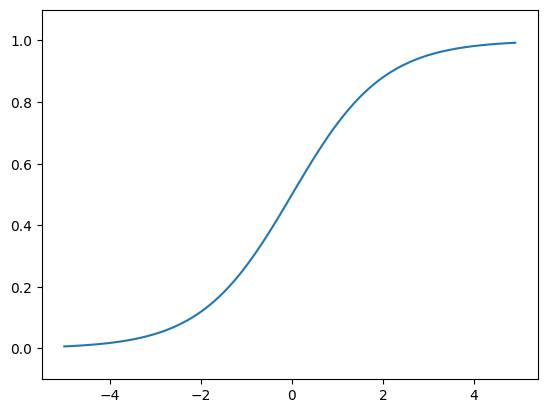

In [26]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定
plt.show()

シグモイド関数とステップ関数を見比べてみる．

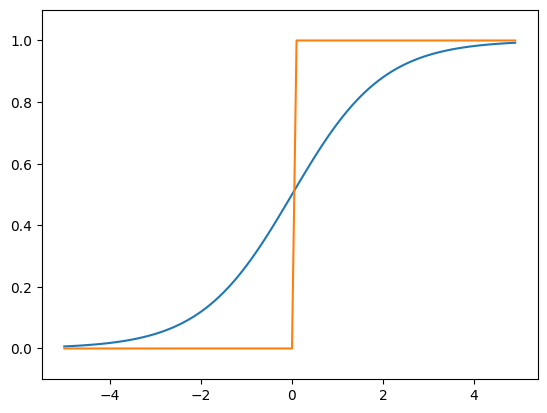

In [27]:
x = np.arange(-5.0, 5.0, 0.1)
y_sig = sigmoid(x)
y_stp = step_function(x)
plt.plot(x, y_sig)
plt.plot(x, y_stp)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定
plt.show()

- 違う点
    - 滑らかさ：
        - シグモイド関数はなめらかな曲線で，入力に対して連続的に出力が変化する．一方，ステップ関数は0を境に急に出力を変える．シグモイド関数の滑らかさが，ニューラルネットワークの学習において重要な意味を持つ．
- 共通点
    - 大まかな形：
        - 両方とも入力が小さいときに出力は0に近く(0であり)，入力が大きくなるに従い，出力が1に近づく(1になる)．つまり，入力信号が重要な情報であれば大きな値を出力し，入力信号が重要でなければ小さな値を出力する．
        - どんなに大きな(小さな)値が入っても，出力信号の値は0から1の間に押し込められる．
    - 非線形関数である：
        - シグモイド関数は曲線，ステップ関数は階段のような折れ曲がった直線．
        
### ReLU関数を作る
シグモイド関数はニューラルネットワークの歴史において，古くから利用されてきたが，最近ではReLU (Rectified Linear Unit) という関数が用いられている．ReLUは入力が0を超えていれば，その入力をそのまま出力し，0以下なら0を出力する関数である．

ReLU関数は以下の式で表される．

$$h(x) = \begin{cases} x & (x > 0) \\ 0 & (x \le 0) \end{cases}$$

> ReLUについても，こういうもんだということでご理解ください．

ReLU関数を以下のように実装する．

In [28]:
def relu(x):
    return np.maximum(0, x) # 入力された値から大きい方の値を選んで出力する

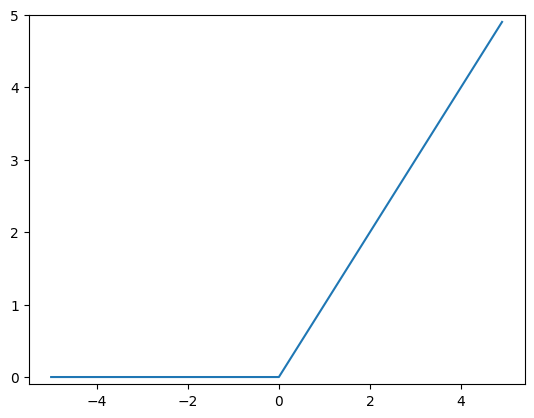

In [29]:
x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-0.1, 5.0) # y軸の範囲を指定
plt.show()

> ここまではニューラルネットワークの活性化関数を作ってきました．これでほぼニューラルネットワークを作れます．

> 複数の入力に重み(W)をかけて，それらとバイアス(b)の総和を活性化関数に入力して，活性化関数の出力にさらに重みをかけて，それらとバイアスの総和を計算し，次の層の活性化関数入力する．．．という感じでニューラルネットワークでは何層も繰り返し，同様の計算をしながら，最終的な出力を出します．ただ，何のためにこんな計算をするのかイメージできないですよね．

> 何のための計算をしているのか，わからないままだと，退屈だと思いますので，少し脱線して，今回のLessonの最後でやる，手書きの数字画像の認識を例にして，何のために計算しているのかを説明しますね．例えばWやbを適切に設定して (次のLessonで適切な重み，バイアスを設定するための学習方法を学びます)，手書き数字の画像の画素値 (画像を構成する点の数値です．モノクロ画像だと点の明るさが大きくなる(白くなる)ほど画素値が大きくなります) を入力し，最初のWと画素値との掛け算をして，bとの総和を計算して，最初の活性化関数に入力します．さらに活性化関数の出力にWを掛け，bとの総和を取り，次の活性化関数に入力して．．．という感じで，さいごの活性化関数の出力まできます．そして，その画像が「0」だったら最後の活性化関数のうち，0番目の活性化関数の出力が一番大きくなり，画像が「1」だったら1番目の活性化関数の出力が一番大きくなる．．．ということが答を出す (テキストの最初に示したニューラルネットワークの例では最後の層の活性化関数の数は2個ですが，数字を認識するときは最後の活性化関数は10個必要になります)，ということができるようになります．これはWやbが適切に設定されていることが前提になりますが，それさえしていれば，同じような単純な計算の繰り返しで (掛け算して，和をとって，活性化関数に入れての繰り返しですよね)，手書きの数字というあいまいな画像の認識ができるんですね．

<img alt="forward.png" width="400" src="http://drive.google.com/uc?export=view&id=1eVp1bncTMUmNnCxNASyuTa1tWc8b13Bn">

> 重みやバイアスを変えると，猫と犬を分類するためのニューラルネットワークになったりして，同じ計算をしているのに，違う仕事ができるようになります．ニューラルネットワークの良さといいますか，何のためにこの計算をやっているのかイメージできましたでしょうか．

> ちなみに，活性化関数を何種類か作りましたが，活性化関数を変えると，数字の認識が得意になったり，猫・犬の認識が得意になったり．．．という感じで得意な仕事が変わります．

### 行列を使ってニューラルネットワークの計算を効率的にする

#### 念の為行列の積について思い出す

3×2の行列の例．

<img alt="matrix.png" width="150" src="http://drive.google.com/uc?export=view&id=18fBM9D3iwMih5HG9JbmUjdrAAlAiasWK">

行列の積の例．

<img alt="matrix_dot.png" width="300" src="http://drive.google.com/uc?export=view&id=1j8LOpQfOCU_io1zCTGhwgWU_fUPG_DgD">

> すでにほかの授業で行列の積については習っていますかね．

#### ここから本番

以下のようなニューラルネットワークで行列を使った計算の効率化をしてみる．
ただし，ここではバイアスと活性化関数は省略して，重みのみがあるとする．

<img alt="fig_dot.png" width="150" src="http://drive.google.com/uc?export=view&id=1DyxjSUT5ZqprLGwkJtqeQ899UhBwyC1r">

このニューラルネットワークの入力と重みからYを算出するのに，以下のような行列の積を考えると効率的に計算できる．

<img alt="form_dot.png" width="400" src="http://drive.google.com/uc?export=view&id=1m2D--Dc8URvAjMyE_qArZyeZr2VkFmXN">

こうすることで，もしXの要素が100や1000であったとしても一度の演算で計算できる！  
***もしこの計算方法が使えなければ，Xの要素を一つずつ取り出して計算しなければならない***

> 上記のように行列の積を計算することで，入力と重みの掛け算をして総和を取る計算がいっぺんにできていることがわかりますね．

この演算は以下のように行う．

In [30]:
X = np.array([1,2])
X.shape

(2,)

> ひとまず入力は1と2にしましょう．なんでもいいです．

In [31]:
W = np.array([[1,3,5],[2,4,6]])
W

array([[1, 3, 5],
       [2, 4, 6]])

> 重みは上の例と同じですね．

In [32]:
W.shape

(2, 3)

> 2行3列であるとわかりますね．上の例と同じです．

In [33]:
Y = np.dot(X, W)
Y

array([ 5, 11, 17])

> これで積の計算ができます．

In [34]:
Y.shape

(3,)

> 積の結果は3列になります．

### 3層ニューラルネットワークを作ってみる

今まで習ったことである，活性化関数と行列を使った計算とを使って，”実践的”なニューラルネットワークを作ってみる．まずは，下の図のような3層のニューラルネットワークを作ってみて，入力から出力への処理をやってみる．

<img alt="3layers.png" width="400" src="http://drive.google.com/uc?export=view&id=15gXgemChEO7wVIG9zkV2Tn9w66eOq5qm">

このままだとどう作るか考えにくいので，まずは第1層目の1番目のニューロンへの信号の伝達を見てみる．  
(カッコで囲んだ数字は層の番号で，下付き文字は何番目のニューロンかを表す．下付き文字が二桁の場合は，左が次の層，右が前の層のニューロンの番号を表す)

<img alt="3layers_1.png" width="400" src="http://drive.google.com/uc?export=view&id=1kAslGwrwL_eSvifzOdiUPnxzqC-fexQc">

<!-- 3layers_1 -->
<img src="http://drive.google.com/uc?export=view&id=1z16jx089-VesAsbzLqYPxNwqa14WkcVB" width="50%">

これを行列の積を用いて計算する場合，以下のようになる．

$$A^{(1)} = XW^{(1)} + B^{(1)}$$

$$
A^{(1)} = \begin{pmatrix} a_1^{(1)} & a_2^{(1)} & a_3^{(1)} \end{pmatrix},
X = \begin{pmatrix} x_1 & x_2 \end{pmatrix},
B^{(1)} = \begin{pmatrix} b_1^{(1)} & b_2^{(1)} & b_3^{(1)} \end{pmatrix},
$$

$$
W^{(1)} = \begin{pmatrix}
w_{11}^{(1)} & w_{21}^{(1)} & w_{31}^{(1)} \\
w_{12}^{(1)} & w_{22}^{(1)} & w_{32}^{(1)}
\end{pmatrix}
$$

> XWの部分が上でやった掛け算と足し算をいっぺんにやるための積ですね．これにバイアスであるBを足しています．これはパーセプトロンでやったことと同じですね．

これを実装する．

In [35]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5],[0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

A1 = np.dot(X, W1) + B1

In [36]:
A1

array([0.3, 0.7, 1.1])

入力と重みとバイアスからa (重み付き和) が求まった．これを活性化関数に入れて，第1層での処理が完成！

<img alt="3layers_2.png" width="400" src="http://drive.google.com/uc?export=view&id=1wuiQxMpUmWNgSCqqSTGVxImfNl3p71cm">


In [37]:
Z1 = sigmoid(A1)

In [38]:
Z1

array([0.57444252, 0.66818777, 0.75026011])

> これで1層目の計算ができましたね．ここでは重みに適当な値を入れているので，特に意味のある計算にはなっていません．

続いて第1層から第2層を作る．

<img alt="3layers_3.png" width="400" src="http://drive.google.com/uc?export=view&id=14DT9k-HjIOUoMd_yRjE_64O51vcrNgrl">

第1層と同じように以下のように実装する．

In [39]:
W2 = np.array([[0.1, 0.4],[0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

A2 = np.dot(Z1, W2) + B2 # 第1層の出力が第2層の入力になる
Z2 = sigmoid(A2)

In [40]:
Z2


array([0.62624937, 0.7710107 ])

最後に第2層から出力層を作る．

<img alt="3layers_4.png" width="400" src="http://drive.google.com/uc?export=view&id=1niYXs42JoQdmxl9YvG8OXMoICwt72fOk">

出力層もこれまでとほとんど同じだが，活性化関数がこれまでの隠れ層と異なる．

以下でidentity_function() という関数を定義している．これは「恒等関数」といい，出力層の活性化関数として利用する．
恒等関数は入力をそのまま出力する関数である．出力層の活性化関数はσ()で表し，隠れ層の活性化関数h()とは異なることを示している．

> 最後の活性化関数だけ，それ以前の隠れ層の活性化関数とは違うものを設定します．


In [41]:
def identity_function(x):
    return x # 入力をそのまま出力する

In [42]:
W3 = np.array([[0.1, 0.3],[0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

In [43]:
Y


array([0.31682708, 0.69627909])

このように，ニューラルネットワークの入力から出力への処理を作ることができた．このような入力から出力方向への伝達処理をforwardと言う．あとで説明する，ニューラルネットワークの学習では逆向きの流れになり，backwordと呼ばれる．

ではこれまでのforwardの実装をまとめる．

In [44]:
def init_network():
    network = {} # ディクショナリでWとbを定義する
    network['W1'] = np.array([[0.1, 0.3, 0.5],[0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4],[0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3],[0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])

    return network

def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)

    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)

In [45]:
y

array([0.31682708, 0.69627909])

> 上記はこれまで1層ずつ処理してきたことを，まとめて書き直しただけです．最後の出力であるyが同じ値になっていることがわかりますね．
ただ，ディクショナリを使って，すっきりと書き直しています．

> 次にもう1種類の出力層(最後の層)の活性化関数であるソフトマックス関数を作ります．

### 出力層の設計

#### 出力層の活性化関数

- 恒等関数 (上で作ったもの)
    - 入力をそのまま出力する
    - 回帰問題で用いる
- ソフトマックス関数
    - 入力を「確率」として解釈可能とする
    - 分類問題で用いる
    
> 回帰は身長から体重を推定するような問題でしたね．分類は，これからやろうとしている手書き数字の画像を入れて，それが1なのか，2なのか．．．ということを分類する問題ですね．こういった分類問題では最後の層でソフトマックス関数を用います．

#### ソフトマックス関数
ソフトマックス関数は以下の式，図で表される．

<img alt="softmax.png" width="180" src="http://drive.google.com/uc?export=view&id=1GQiU5Q6pGUon9k7m9i3L6-KicBWoszRg">

> ソフトマックスは全体分のそれぞれのノードという割り算の計算になっていますので，確率を出しているような感じですよね．

これをそのまま実装すると少し問題がある．


In [46]:
a = np.array([1010, 1000, 990])
np.exp(a) / np.sum(np.exp(a))

/tmp/ipykernel_10958/832863605.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(a) / np.sum(np.exp(a))
/tmp/ipykernel_10958/832863605.py:2: RuntimeWarning: invalid value encountered in divide
  np.exp(a) / np.sum(np.exp(a))


array([nan, nan, nan])

ソフトマックス関数は指数関数の計算を行う．この際，指数関数の値が大きくなることがよくある．例えばeの1000乗は無限大を示すinfが返される (オーバーフローしている)．

> 取り扱える数字には上限があり，それを超える大きさの数字は取り扱えなくて，infと表示されてしまいます．

In [47]:
np.exp(1000)

/tmp/ipykernel_10958/2006519253.py:1: RuntimeWarning: overflow encountered in exp
  np.exp(1000)


np.float64(inf)

このような大きな値同士で割り算を行うと，数値が"不安定"な結果になる．これを避けるために，ソフトマックス関数の式を以下のように変える．

\begin{aligned}
y_k &= \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}} = \frac{Ce^{a_k}}{C\sum_{i=1}^{n} e^{a_i}} \\
&= \frac{e^{(a_k + \log C)}}{\sum_{i=1}^{n} e^{(a_i + \log C)}} \\
&= \frac{e^{(a_k + C')}}{\sum_{i=1}^{n} e^{(a_i + C')}}
\end{aligned}

> aに同じ値を足し算したり引き算したりしても計算結果は変わらないんですね．

ソフトマックスの指数関数の計算の際には，何らかの定数を足し算しても結果は変わらない．これを利用して以下のように実装する．

In [48]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # オーバーフロー対策で入力された値の中の最大値でそれぞれの値を引き算する
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

In [49]:
a = np.array([1010, 1000, 990])
y = softmax(a)
y

array([9.99954600e-01, 4.53978686e-05, 2.06106005e-09])

> 確率なので全部合計すると1になります．

In [50]:
np.sum(y)

np.float64(1.0)

#### 出力層のニューロンの数

出力層のニューロンの数は何を出力したいかによって決める．画像から0～9の数字がどれかを予想する問題は，10クラス分類問題なので，出力層のニューロンは10個にすれば良い．

> これは上でちょっと先に説明しましたよね．

<img alt="no_of_output.png" width="450" src="http://drive.google.com/uc?export=view&id=1rstXOQJXRBgV_1mdmCpwtvzUqNbGzhYJ">

### 手書き数字を認識してみる
> せっかく作ったので，何か役立つことをやってみたいですよね．

ここで，手書きの数字画像の分類をやってみる．
学習はすでに完了したものとして，学習済みのパラメータ (重みとバイアス) を使って，ニューラルネットワークの「推論処理」だけを作ってみる．

MNISTデータセットを使う．MNISTは機械学習の分野で最も有名なデータセットの一つである．

<img alt="mnist.png" width="300" src="http://drive.google.com/uc?export=view&id=1HXR6dx4wApD9xPh5IRi8ku1UEpDVSUb5">

- 28×28のサイズ
- 各ピクセルは0から255までの値
- それぞれの画像データに対して「7」，「2」，「1」といった対応するラベルがついている

> ラベルは答えのことですね．

以下でMNISTをダウンロードして，ローカルのファイルに保存する．1回目はダウンロードするので時間がかかるが，2回目以降はファイルを参照するのですぐに終了する．

In [51]:
!pwd

/content


In [1]:
from google.colab import drive
import sys

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/data'

Mounted at /content/drive


In [53]:
!ls ./drive/MyDrive/data/

mnist_X.pkl  mnist_y.pkl  sample_weight.pkl


> save_dirにはMNISTデータを保存するフォルダを指定してください．マイドライブ以下の場合は
 '/content/drive/My Drive/***'
 のようにすればよいはずです．


In [54]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import pickle
import os

# データをダウンロード
mnist_X, mnist_y = fetch_openml("mnist_784", version=1, return_X_y=True)

# 型変換と正規化
X = mnist_X.astype("float32").to_numpy() / 255.0
y = mnist_y.astype(int).to_numpy()

# pickleで保存
with open(os.path.join(save_dir, 'mnist_X.pkl'), 'wb') as f:
    pickle.dump(X, f)

with open(os.path.join(save_dir, 'mnist_y.pkl'), 'wb') as f:
    pickle.dump(y, f)

# 学習用と評価用に分割（シードを固定）
x_train, x_test, t_train, t_test = train_test_split(X, y, test_size=10000, random_state=42)

> 上のプログラムでインターネットから手書き数字の画像とラベルをダウンロードして，```(x_train, t_train), (x_test, t_test)```に入れています．

> 補足説明
- fetch_openmodel: Scikit-learnの関数 sklearn.datasets.fetch_openml を用いることで，様々なデータセットをダウンロードすることができます．今回は "mnist_784" というデータの version1 を (画像，正解ラベル) のタプル形式で取得しています．
- 正規化: 元の画像データ mnist_X は各ピクセルが0～255までの値をとります．ニューラルネットワークの安定性のため，全体を255で割り，0～1に押し込んでいます．このような前処理を正規化と呼びます．
- pickle化: Python標準ライブラリのpickleを使って，ダウンロードしたデータを保存しています．2回目以降はダウンロードを行うのではなく，このファイルを読み込めばよいことになります．
- train_test_split: Scikit-learnの train_test_split という関数を使ってMNISTデータを(訓練画像，訓練ラベル)，(テスト画像，テストラベル)という形式で分割しています．ここではテストの画像を10000枚と指定し，データ分割における乱数のシードを固定しています．シードを固定することで実験の再現性が得られます．
        
MNISTデータセットの形状を見てみる．

In [55]:
x_train.shape

(60000, 784)

> 784はピクセル(画素)の数ですね．28×28は784ですからね．1列になった画像が60000枚入っていることがわかりますね．

In [56]:
t_train.shape

(60000,)

> これはラベルですね．画像が「0」なのか，「1」なのか．．といった答えが入っています．試しに1つ見てみましょうか．

In [57]:
t_train[123]

np.int64(8)

> 123番目の画像は8であることがわかりますね．

> testのデータについても下記のように同様です．

In [58]:
x_test.shape

(10000, 784)

In [59]:
t_test.shape

(10000,)

MNISTデータセットの中身を見てみる．

> せっかくなので，実際に手書き数字の画像を表示してみましょう．下記の関数を作って，画像を表示できるようにしましょう．

In [60]:
from PIL import Image
import IPython

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img*255.0))  # 画素値を0～255に戻す
    pil_img.show()
    pil_img.save("test.png")

In [61]:
label = t_train[123] # ラベルを確認
label

np.int64(8)

In [62]:
img = x_train[123] # 画像の形状を確認
img.shape

(784,)

In [63]:
img = img.reshape(28, 28) # 形状を28x28の画像サイズに変形
img.shape

(28, 28)

In [64]:
img_show(img)
IPython.display.Image("test.png")

> 画像が表示されましたか？なお，```img = img.reshape(28, 28) ```で1列になっていた画像の画素を28×28に整形しています．これを```img_show(img)```で表示しているんですね．

これでデータを用意できたので，推論処理を行うニューラルネットワークを作る．
- 入力層のニューロン：784個 (画像のサイズ)
- 出力層のニューロン：10個 (10クラス分類)
- 隠れ層の数：2つ
    - 1つ目の隠れ層のニューロン：50個
    - 2つ目の隠れ層のニューロン：100個
    > 隠れ層のニューロンの数は今回はこのようにしています．ただ，この数でないといけないわけではありません．いくつにすると精度よく推定できるのか，本来はいろいろと試しながら調整する必要があります．

In [65]:
import pickle # 学習済みの重み，バイアスをファイルから読み込むため，ライブラリを最初に読み込む
save_dir = '/content/drive/My Drive/data'

def get_data(): # MNISTのデータを読み込む関数
    with open(os.path.join(save_dir, 'mnist_X.pkl'), 'rb') as f:
      X = pickle.load(f)
    with open(os.path.join(save_dir, 'mnist_y.pkl'), 'rb') as f:
      y = pickle.load(f)

    x_train, x_test, t_train, t_test = train_test_split(X, y, test_size=10000, random_state=42)

    return x_test, t_test

def init_network():
    with open(os.path.join(save_dir, 'sample_weight.pkl'), 'rb') as f:
        network = pickle.load(f) # 上ではニューラルネットワークの重みやバイアスを1つ1つ設定したが，ここではファイルから読み込む

    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

> さっきもニューラルネットワークのプログラムを作っていただきましたが，それとよく似ていると思います．```def init_network():```はさっきは重み，バイアスを1つ1つ設定しましたが，ここでは，数字の画像を認識するための学習済みの重み，バイアスをファイルから読み込んでいます．また，```def predict(network, x):```はさっきは```def forward(network, x):```という名前でしたが，やっていることは同じですね．最後の活性化関数がソフトマックスに変わっているだけです．今回は，分類問題ですから，最後はソフトマックスになるんですね．

In [66]:
x, t = get_data()
network = init_network()

> これで```x```と```t```に画像とラベルが入ります．また，```network```には重みとバイアスが入ります．

In [67]:
t

array([8, 4, 8, ..., 3, 8, 3])

> ```t```にはラベル(正解)が入っていることがわかりますね．

In [68]:
img_show(x[1].reshape(28,28))
print(t[1])
IPython.display.Image("test.png")

4


> ちゃんと画像の内容とラベルがあっていることがわかりますね．これで準備完了です！あとは以下のようにして，画像に書かれている数字が何か，推定できます．試しに1番目の数字が何か推定してみましょう．正解は「4」ですが，正しく推定できるでしょうか．．．

In [69]:
y = predict(network, x[1].flatten())
y

array([4.5174900e-07, 3.4104360e-05, 9.1649890e-06, 9.6246447e-05,
       9.7699410e-01, 7.2747283e-04, 2.0354129e-04, 4.5800833e-03,
       1.7499849e-04, 1.7179728e-02], dtype=float32)

> はい．ここではone-hot表現になるんですね．配列の中で4番目の数字が一番大きくなっているかどうかを確認してみましょう．ちなみに，```e-07```は10のマイナス7乗という意味です．

> うまく推定できていそうですね (0番目から始まることを忘れずに)．目でみて何番目が一番大きいか確認するのは大変ですから，下記のようにして，すぐに答えがわかるようにするとよいですね．

In [70]:
p = np.argmax(y) # 最も確率の高い要素のインデックスを取得
p

np.int64(4)

認識精度を評価する

In [71]:
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy: " + str(float(accuracy_cnt) / len(x)))

Accuracy: 0.936


> 上のプログラムはすべての画像を使って推定し，そのうちのいくつが正解したかをカウントし，全体のうち，どれくらいの割合で正解するかを計算します．  
> ```for i in range(len(x)):```は画像が入っている```x```の画像の数 (10000まいですね) だけ，その下の処理を繰り返します．```i```には画像のインデックス(0番目から数えて何番目か)が入ります．  
> ```y = predict(network, x[i])``` で推定しています．さっきやった通りですね．i番目の画像を指定しています．  
> ```p = np.argmax(y)``` もさっきやった通り，one-hot表現の形式から，推定結果の数字を取り出しているんですね．
```
    if p == t[i]:
        accuracy_cnt += 1
```        
> これで，正解だったら``` accuracy_cnt```に1を足しています．これを繰り返すことで，いくつ正解したかが``` accuracy_cnt```に入ります．  
> ```(accuracy_cnt) / len(x)```で正解した数を全体で割って，割合を出しています．

#### バッチ処理
一度に複数枚の画像を入力する事もできる．まとまりのある入力データをバッチと呼び，まとめて入力することで処理時間を短縮できる．

In [72]:
batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy: " + str(float(accuracy_cnt) / len(x)))

Accuracy: 0.936


> 確かに同じ精度になっているので，うまく動いていそうですが，下記でもう少し詳しく動作を説明します．

少しわかりにくいのでバラバラにして説明する．まずrange()関数の使い方について．

In [73]:
list(range(0,10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [74]:
list(range(0,10,3))

[0, 3, 6, 9]

> 上記のようにすると，0～10で3刻みの値をもらえるんですね．なので，```range(0, len(x), batch_size```とすると，len(x)は画像の枚数なので10000，```batch_size = 100```だから，```[0, 100, 200, ...]```となりますね．  
また，```x_batch = x[i:i+batch_size]```は範囲指定で複数の画像を取ってきているんですね．1回目は0～100番目，2回目は100～200番目という風に100枚ずつ取ってきて，推定します．

次にargmax関数の使い方について．axis = 1を指定することで，1次元目の要素ごとに最大値のインデックスを見つけるようになる．

> ちょっとわかりにくいと思いますので，下記のように例を使って何をやっているのか確認しましょう．

In [75]:
x = np.array([[0.1, 0.8, 0.1], [0.3, 0.1, 0.6], [0.2, 0.5, 0.3], [0.8, 0.1, 0.1]])
x

array([[0.1, 0.8, 0.1],
       [0.3, 0.1, 0.6],
       [0.2, 0.5, 0.3],
       [0.8, 0.1, 0.1]])

> xは上記のように4行3列の行列ですね．

In [76]:
y = np.argmax(x, axis=1)
y

array([1, 2, 1, 0])

> ```axis=1```とすると，上から順番に何番目が一番大きいかを確認していきます．一番上は```[0.1, 0.8, 0.1]```ですから，1番目が一番大きいので，1となります．

In [77]:
y = np.argmax(x, axis=0)
y

array([3, 0, 1])

> ```axis=0```とすると，左から順番に何番目が一番大きいかを確認していきます．一番左は```0.1, 0.3, 0.2, 0.8```ですから，3番目が一番大きいので3となります．

最後にバッチ単位で分類結果と答えを比較するところについて．

> ```np.sum(p == t[i:i+batch_size])```の部分ですね．これも下記のように例を使ってみてみましょう．  
```p```は推定結果で，```[1, 2, 1, 0]```と推定したとしましょう．また，```t```はラベルで，正解は```[1, 2, 0, 0]```としましょう．この場合は，4つのうち1個不正解ですから，正解の数は3です．これを下記のようにして数えています．

In [78]:
p = np.array([1, 2, 1, 0])
t = np.array([1, 2, 0, 0])
p == t

array([ True,  True, False,  True])

In [79]:
np.sum(p == t)

np.int64(3)